In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
df_preds = pd.read_csv('nnces_predictions.csv')
print(f"Загружено {len(df_preds)} записей")
df_preds.head()

Загружено 5000 записей


,filename,age_predicted,gender_predicted,age_true,gender_true
0,10Y/Boys_10/M13/M13_04/M13_04_09.wav,29.259869,female,10,male
1,10Y/Boys_10/M13/M13_04/M13_04_01.wav,30.379993,female,10,male
2,10Y/Boys_10/M13/M13_04/M13_04_10.wav,28.024985,female,10,male
3,10Y/Boys_10/M13/M13_04/M13_04_06.wav,29.752246,female,10,male
4,10Y/Boys_10/M13/M13_04/M13_04_05.wav,28.849223,female,10,male


In [5]:
# Вычисляем ошибки
df_preds['error'] = df_preds['age_predicted'] - df_preds['age_true']
df_preds['abs_error'] = abs(df_preds['error'])
df_preds['squared_error'] = df_preds['error'] ** 2

# Основные метрики
MAE = df_preds['abs_error'].mean()
MSE = df_preds['squared_error'].mean()
RMSE = np.sqrt(MSE)
STD_ERROR = df_preds['error'].std()

# Процент ошибок в пределах
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100

print("Метрики оценки")

print(f"\n Основные метрики:")
print(f"  MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"  RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"  Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\n Процент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:  {within_10_years:.1f}%")

print(f"\n Статистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

 Основные метрики:
  MAE  (Mean Absolute Error):     21.979 лет
  RMSE (Root Mean Squared Error): 22.107 лет
  Std of Error (разброс ошибок):  2.374 лет

 Процент ошибок в пределах:
  ≤ 1 год:   0.0%
  ≤ 3 года:  0.0%
  ≤ 5 лет:   0.0%
  ≤ 10 лет:  0.0%

 Статистика абсолютных ошибок:
  Мин ошибка:  14.706 лет
  Медиана:     22.009 лет
  Макс ошибка: 30.884 лет


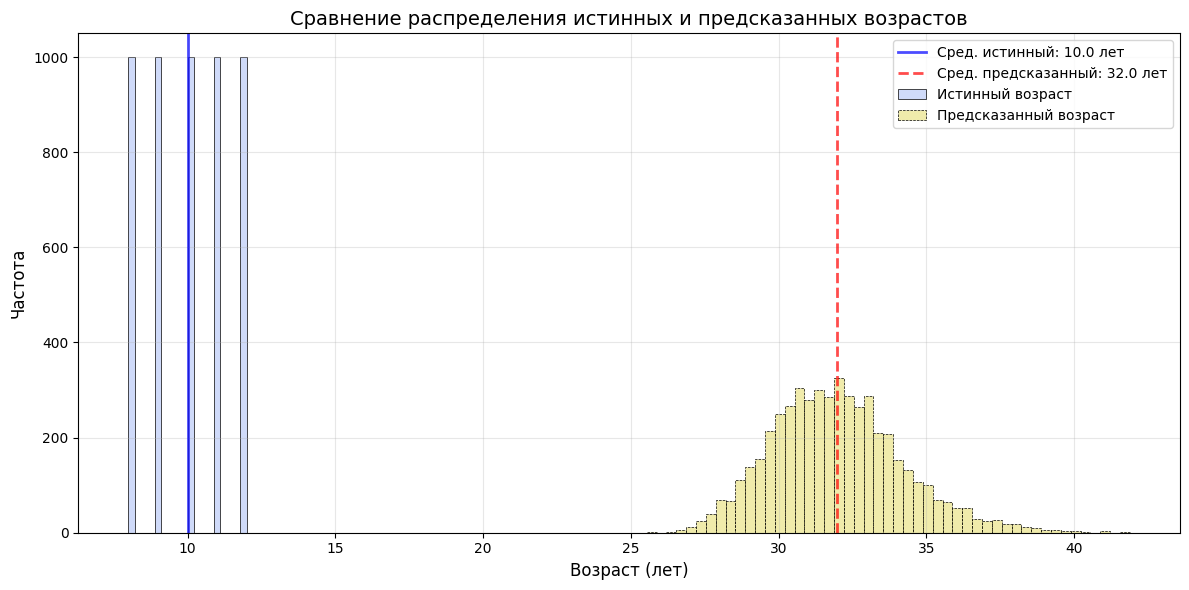

In [9]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='age_true', 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='age_predicted',
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['age_true'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["age_true"].mean():.1f} лет')
plt.axvline(df_preds['age_predicted'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["age_predicted"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()